<span style="float: left;padding: 1.3em">![logo](https://github.com/gw-odw/odw/blob/main/Tutorials/logo.png?raw=1)</span>

# Gravitational Wave Open Data Workshop

## Challenge 3 (Itermediate)




*   Use the data file challenge3.gwf with channel H1:CHALLENGE3.
*   These are real LIGO data from O2, though we've adjusted the time labels and added some simulated signals.
*   The data contain a loud simulated signal with m1 = m2 = 10 solar masses.




1.   What is the merger time of this signal?
2.   What is the matched-filter SNR of this signal?






























In [ ]:
# Those 2 lines are just to avoid some harmless warnings when importing packages
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

> ⚠️ **Warning**: restart the runtime after running the cell below.
>
> To do so, click "Runtime" in the menu and choose "Restart and run all".

In [ ]:
# -- Use the following for Google Colab
! pip install -q "lalsuite==7.25.1"
! pip install --no-build-isolation pycbc
!pip install numpy==1.23.5
! pip install -q 'gwosc==0.7.1'

# Section 1: Load the data into memory.

In [ ]:
! pip install -q lalsuite
! pip install -q gwpy
! pip install -q pycbc
# -- Click "restart runtime" in the runtime menu

# -- download data
! wget https://dcc.ligo.org/public/0187/G2300818/001/challenge3.gwf

# -- for gwpy
from gwpy.timeseries import TimeSeries
gwpy_strain = TimeSeries.read('challenge3.gwf', channel="H1:CHALLENGE3")

# -- for pycbc
from pycbc import frame
pycbc_strain = frame.read_frame('challenge3.gwf', 'H1:CHALLENGE3')

--2025-05-22 03:01:13--  https://dcc.ligo.org/public/0187/G2300818/001/challenge3.gwf
Resolving dcc.ligo.org (dcc.ligo.org)... 131.215.125.133
Connecting to dcc.ligo.org (dcc.ligo.org)|131.215.125.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 256814830 (245M)
Saving to: ‘challenge3.gwf.5’

challenge3.gwf.5    100%[===================>] 244.92M  41.1MB/s    in 5.5s    

2025-05-22 03:01:20 (44.3 MB/s) - ‘challenge3.gwf.5’ saved [256814830/256814830]



XLAL Error - XLALFrFileOpenURL (LALFrameIO.c:123): Could not open TOC for frame file /content/challenge3.gwf
XLAL Error - XLALFrFileOpenURL (LALFrameIO.c:123): I/O error
XLAL Error - XLALFrStreamFileOpen (LALFrStream.c:138): Internal function call failed: I/O error
XLAL Error - XLALFrStreamCacheOpen (LALFrStream.c:210): I/O error
XLAL Error - XLALFrStreamOpen (LALFrStream.c:264): Internal function call failed: I/O error


RuntimeError: Internal function call failed: I/O error

# 1. Time of the merger?

In [ ]:
print("Sample rate:", gwpy_strain.sample_rate)

print("Duration:", gwpy_strain.duration)

Sample rate: 4096.0 Hz
Duration: 4096.0 s


/usr/local/lib/python3.11/dist-packages/astropy/units/quantity.py:658: RuntimeWarning: invalid value encountered in sqrt
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


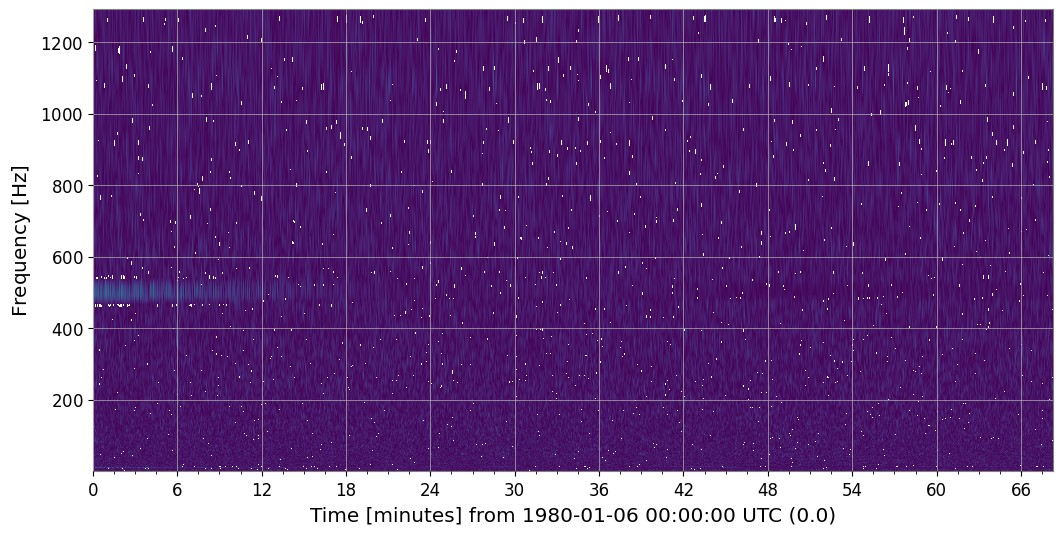

In [ ]:
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries
gwpy_strain = TimeSeries.read('challenge3.gwf', channel="H1:CHALLENGE3", start=0, end=4096)

#Q-transform

q_transform = gwpy_strain.q_transform(fftlength=4, overlap=2, window='hann') ** (1/2.)  #Getting q-transform

plot = q_transform.plot()
plt.show()




In [ ]:
# Libraries to get the Time of Merger, SNR and PSD

from pycbc.frame import read_frame
from pycbc.psd import interpolate, inverse_spectrum_truncation
from pycbc.filter import matched_filter
from pycbc.filter import resample_to_delta_t
from pycbc.filter import highpass
from pycbc.waveform import get_td_waveform
import pylab
import matplotlib.pyplot as plt




In [ ]:
#To read the data

start = 0
end = start + 256 #since the signal is very large, we cut it to 256 instead of working with the 4096

ts = read_frame('challenge3.gwf', 'H1:CHALLENGE3', start, end)



#Defining conditioned

In [ ]:
#Processing the signal

strain = highpass(ts, 15.0) #filter to avoid frequencies lower than 15
strain = resample_to_delta_t(strain, 1.0/2048) #to adjust the sample range

#Defining conditioned based on how much the signal should be cropped

conditioned = strain.crop(0, 2)




#Making our template using "SEOBNRv4_opt"

In [ ]:

# Parameters
m1 = 10 # solar mass units

#Polarization modes
hp, hc = get_td_waveform(approximant="SEOBNRv4_opt", #getting waveform in time_domain
  mass1 = m1,
  mass2 = m1,
  delta_t = 1.0/2048.0, #using the same delta_t as the conditioned data
  f_lower = 20)  # frequency condition


hp.resize(len(conditioned)) # Resize the template to the length of the *processed* conditioned data

template = hp.cyclic_time_shift(hp.start_time)

#to verify sizes
print("Template hp size :", len(hp))
print("Data conditioned size:", len(conditioned))
print("Template size:", len(template))

Template hp size : 520192
Data conditioned size: 520192
Template size: 520192


In [ ]:
#PSD (Power Spectral Desity)

psd = conditioned.psd(4)  # We used 4-second samples in our time series with the Wech method

psd = interpolate(psd, conditioned.delta_f) #Interpolate

# 1/PSD will now act as a filter with an effective length of 4 seconds.
# Since the data has been high-pass filtered above 15 Hz and will have low values
# below this value, we must tell the function not to include frequencies
# below this frequency.

psd = inverse_spectrum_truncation(psd, int(4 * conditioned.sample_rate),
                                  low_frequency_cutoff=15)

#Time of Merger

In [ ]:
#Time merger

snr = matched_filter(template, conditioned, psd=psd, low_frequency_cutoff=20) #Getting SNR
peak = abs(snr).numpy().argmax()
time = snr.sample_times[peak]

print("Time of Merger:", time)


Time of Merger: 0.03271484375


#SNR and Plot

In [ ]:
peak = abs(snr).numpy().argmax()
snrp = snr[peak]
time = snr.sample_times[peak]

print("Mass: {}. We found a signal at {}s with SNR {}".format(m1, time, abs(snrp)))

Mass: 10. We found a signal at 0.03271484375s with SNR 1475.569534117961


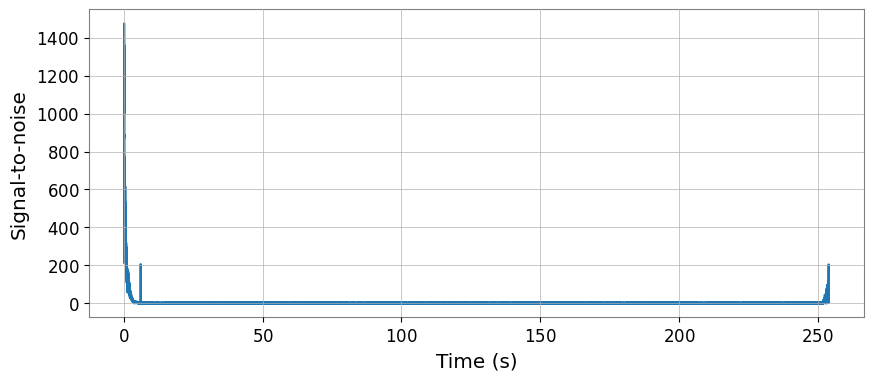

In [ ]:
#PLOT
plt.figure(figsize=[10, 4])
plt.plot(snr.sample_times, abs(snr))
plt.ylabel('Signal-to-noise')
plt.xlabel('Time (s)')
plt.show()


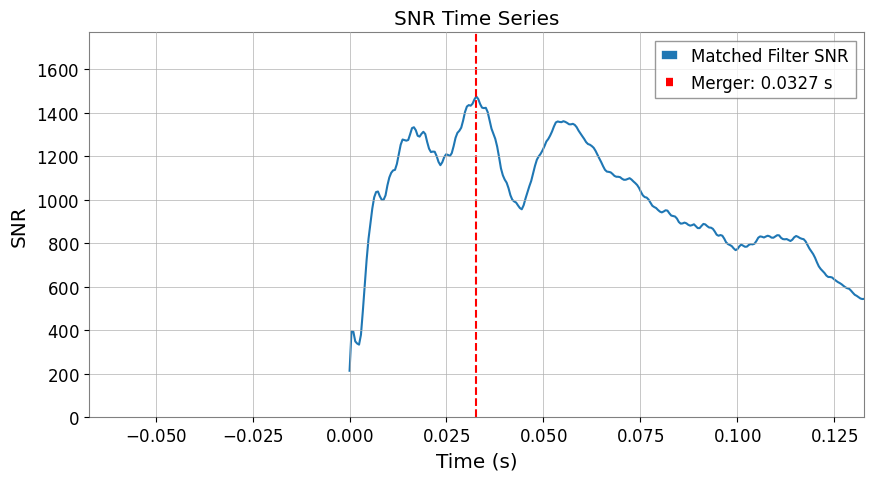

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(snr.sample_times, abs(snr), label="Matched Filter SNR") #We use abs() due to complex signals
plt.axvline(time, color='red', linestyle='--', label=f"Merger: {time:.4f} s")

plt.xlabel("Time (s)")
plt.ylabel("SNR")
plt.title("SNR Time Series")
plt.legend()
plt.grid(True)

# Zoom
plt.xlim(time - 0.1, time + 0.1)  # 0.1 s around the merger
plt.ylim(0, abs(snr).max() * 1.2)  # vertical scale
plt.show()


In [ ]:
#Plot to visualize q-transform by adjusting to the center of merger

#it takes 12 minutes of running

#t0 = float(time)
#q_zoom = gwpy_strain.q_transform(outseg=(t0 - 0.05, t0 + 0.05))

#plot = q_zoom.plot()
#ax = plot.gca()
#ax.set_yscale('log')
#ax.set_ylim(20, 300)
#ax.colorbar(norm='log', label=r"Amplitude [$1/\sqrt{\mathrm{Hz}}$]")
#ax.axvline(t0, color='r', linestyle='--', label='Time of Merger')
#ax.legend()
#plt.title('Q-Transform around Merger Time')
#plot.show()


 # Time-domain template waveform using approximate SEOBNRv4_opt.Plot

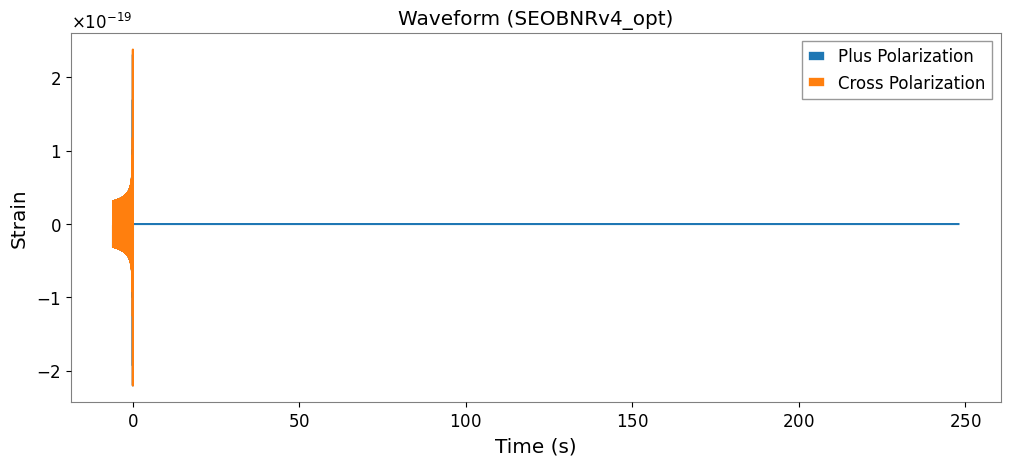

In [ ]:
# Waveform plot

plt.figure(figsize=plt.figaspect(0.4))
plt.plot(hp.sample_times, hp, label='Plus Polarization')
plt.plot(hc.sample_times, hc, label='Cross Polarization')
plt.title("Waveform (SEOBNRv4_opt)")
plt.xlabel('Time (s)')
plt.ylabel('Strain')
plt.legend()
plt.grid()
plt.show()

#3.   PSD of the data and plot this on a log-log scale.

Text(0, 0.5, 'Strain Noise Density')

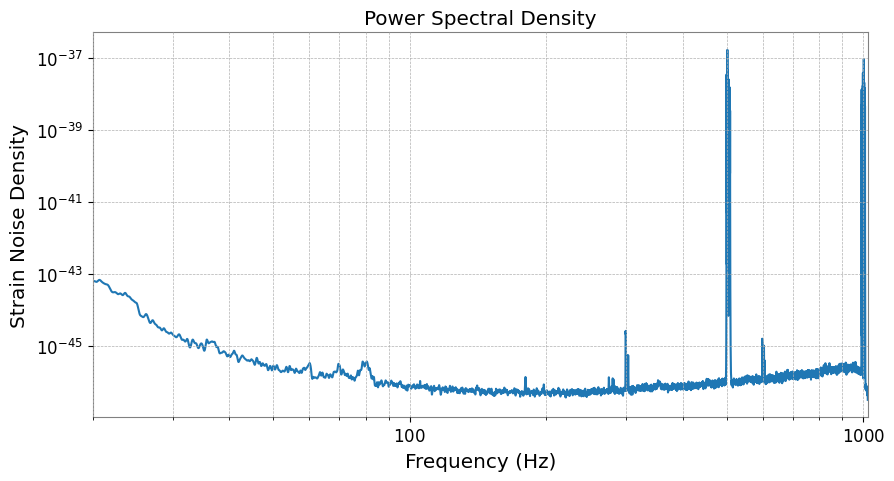

In [ ]:
# PSD Plot
plt.figure(figsize=(10, 5))
pylab.loglog(psd.sample_frequencies, psd, label='PSD')
plt.title('Power Spectral Density')
plt.grid(True, which='both', ls='--')
pylab.xlim(20, conditioned.sample_rate*0.5) #Applying nyquist frequency (half of the sample frequency)
pylab.xlabel('Frequency (Hz)')
pylab.ylabel('Strain Noise Density')

#What is the matched filter SNR of the signal?

In [ ]:
#To get the matched filter SNR of the signal
from pycbc.filter import sigma



dt = time - conditioned.start_time  # Compute how much to shift the template


aligned = template.cyclic_time_shift(dt)  # Apply the time shift using cyclic_time_shift(dt)


# Scale the template so that it would have SNR = 1 in this data
aligned /= sigma(aligned, psd=psd, low_frequency_cutoff=20.0)  # Normalize the waveform

# Scale the template amplitude and phase to match the peak SNR value
aligned = (aligned.to_frequencyseries() * snrp).to_timeseries()  # Convert aligned to frequency domain,

# multiply it by the peak SNR value (snrp), and convert it back to the time domain.
aligned.start_time = conditioned.start_time



In [ ]:
# We do it this way so that we can whiten both the template and the data

white_data = (conditioned.to_frequencyseries() / psd**0.5).to_timeseries()
white_template = (aligned.to_frequencyseries() / psd**0.5).to_timeseries()



white_data = white_data.highpass_fir(30., 256).lowpass_fir(300, 256)
white_template = white_template.highpass_fir(30., 256).lowpass_fir(300, 256)


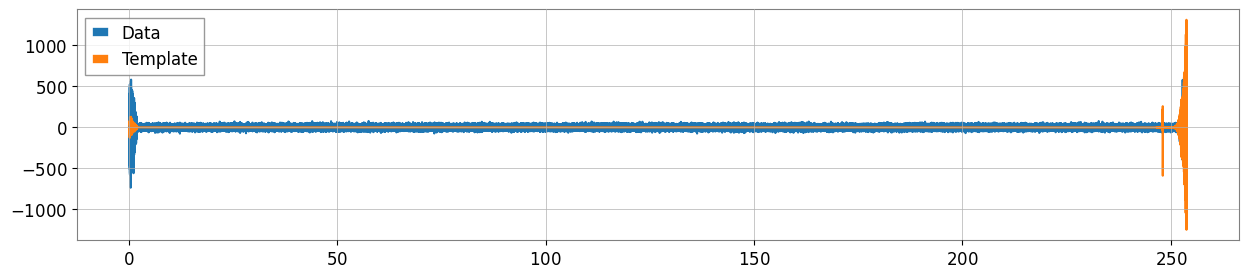

In [ ]:
# Select the time around the merger

# Calculate the desired start and end times
desired_start = time - 0.01
desired_end = time + 0.01

# Ensure the desired start and end times are within the range of the white data


actual_start = max(desired_start, white_data.start_time) # to avoid going early than white_data.start_time, we use max()
actual_end = min(desired_end, white_data.end_time) # to avoid going late than white_data.start_time, we use min()

# Check if the requested slice is valid (start time is not after end time)

if actual_start < actual_end:
    white_data = white_data.time_slice(actual_start, actual_end)
    white_template = white_template.time_slice(actual_start, actual_end)
else:
    print("Warning: The requested time slice is invalid or outside the data range.")



plt.figure(figsize=[15, 3])
plt.plot(white_data.sample_times, white_data, label="Data")
plt.plot(white_template.sample_times, white_template, label="Template")
plt.legend()
plt.show()